In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Image compression system

##Libraries

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
import zlib


In [55]:

# LUMA Matrix (For the Y channel - Preserves detail)
LUMA_QUANT_MATRIX = np.array([
    [16, 11, 10, 16,  24,  40,  51,  61],
    [12, 12, 14, 19,  26,  58,  60,  55],
    [14, 13, 16, 24,  40,  57,  69,  56],
    [14, 17, 22, 29,  51,  87,  80,  62],
    [18, 22, 37, 56,  68, 109, 103,  77],
    [24, 35, 55, 64,  81, 104, 113,  92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103,  99]
])

# CHROMA Matrix (For Cb & Cr channels - Crushes high frequencies aggressively)
CHROMA_QUANT_MATRIX = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])

#Applies 2D Discrete Cosine Transform
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

#Applies 2D Inverse Discrete Cosine Transform
def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

#Calculates Peak Signal-to-Noise Ratio
def calculate_psnr(original, compressed):
    mse = np.mean((original.astype(float) - compressed.astype(float)) ** 2)
    if mse == 0: return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

## Encoder

In [56]:
# ENCODER

# Subtracts DC offset and applies 2D-DCT.
def forward_transform(block):
    return dct2(block - 128)

# Divides by the Quantization matrix and rounds (The Lossy Step).
def quantization(dct_block, Q_matrix):
    return np.round(dct_block / Q_matrix)

# Losslessly compresses the quantized data into a binary stream.
def entropy_encoding(quantized_blocks):
    quantized_array = np.array(quantized_blocks, dtype=np.int16)
    compressed_bytes = zlib.compress(quantized_array.tobytes())
    return compressed_bytes, len(compressed_bytes) * 8, quantized_array.shape

##Decoder

In [57]:
# DECODER

# Decompresses the binary stream back into block matrices.
def entropy_decoding(compressed_bytes, original_shape):
    decompressed_bytes = zlib.decompress(compressed_bytes)
    quantized_array = np.frombuffer(decompressed_bytes, dtype=np.int16)
    return list(quantized_array.reshape(original_shape))

# Multiplies by the Q-matrix to restore approximate frequency values.
def reconstruction_of_quantized_data(quantized_block, Q_matrix):
    return quantized_block * Q_matrix

# Applies Inverse 2D-DCT and adds back the DC offset.
def inverse_transform(dequantized_block):
    return idct2(dequantized_block) + 128

In [58]:
# Executes the pipeline on a single 2D matrix (Y, Cb, or Cr)

def process_single_channel(channel, base_q_matrix, q_scale):
    h_orig, w_orig = channel.shape
    pad_h = (8 - (h_orig % 8)) % 8
    pad_w = (8 - (w_orig % 8)) % 8
    padded = np.pad(channel, ((0, pad_h), (0, pad_w)), mode='edge').astype(float)
    h_padded, w_padded = padded.shape

    Q = np.maximum(np.round(base_q_matrix * q_scale), 1)

    # ENCODER
    quantized_blocks = []
    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            block = padded[i:i+8, j:j+8]
            dct_block = forward_transform(block)
            quantized_block = quantization(dct_block, Q)
            quantized_blocks.append(quantized_block)

    # TRANSMISSION
    compressed_stream, file_size_bits, q_shape = entropy_encoding(quantized_blocks)

    # DECODER
    reconstructed_padded = np.zeros_like(padded)
    received_blocks = entropy_decoding(compressed_stream, q_shape)

    block_idx = 0
    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            q_block = received_blocks[block_idx]
            dequantized_block = reconstruction_of_quantized_data(q_block, Q)
            idct_block = inverse_transform(dequantized_block)
            reconstructed_padded[i:i+8, j:j+8] = idct_block
            block_idx += 1

    # CLEANUP
    reconstructed = reconstructed_padded[:h_orig, :w_orig]
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

    return reconstructed, file_size_bits

# Converts to YCbCr, processes channels with respective matrices and merges.

def process_color_image(img_rgb, q_scale):
    # Convert RGB to YCrCb
    img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_yuv)

    # Process Luminance with LUMA matrix
    rec_y, bits_y = process_single_channel(y, LUMA_QUANT_MATRIX, q_scale)

    # Process Chrominance with harsher CHROMA matrix
    rec_cr, bits_cr = process_single_channel(cr, CHROMA_QUANT_MATRIX, q_scale)
    rec_cb, bits_cb = process_single_channel(cb, CHROMA_QUANT_MATRIX, q_scale)

    # Merge and convert back to RGB
    rec_yuv = cv2.merge([rec_y, rec_cr, rec_cb])
    rec_rgb = cv2.cvtColor(rec_yuv, cv2.COLOR_YCrCb2RGB)

    total_bits = bits_y + bits_cr + bits_cb
    return rec_rgb, total_bits

## Rate Adaptive Algorithm

In [59]:
# RATE ADAPTIVE ALGORITHM (BINARY SEARCH)

# Uses binary search to find the best Q-scale for a target bitrate.
def find_optimal_qscale(img_rgb, target_bits, tolerance=0.02, max_iters=20):
    q_min, q_max = 1.0, 500.0
    best_q, best_recon, best_bits = None, None, -1

    print(f"Target Bitrate: {target_bits:,} bits")

    for iteration in range(max_iters):
        q_test = (q_min + q_max) / 2
        recon_img, current_bits = process_color_image(img_rgb, q_test)
        error_margin = abs(current_bits - target_bits) / target_bits

        if best_bits == -1 or abs(current_bits - target_bits) < abs(best_bits - target_bits):
            best_q, best_recon, best_bits = q_test, recon_img, current_bits

        if error_margin <= tolerance:
            print(f"Target reached: (Iter {iteration+1} | Q: {q_test:.2f} | Bits: {current_bits:,})")
            break

        if current_bits > target_bits:
            q_min = q_test
        else:
            q_max = q_test

    return best_q, best_recon, best_bits

## Execution and testing blocks

Target Bitrate: 382,000 bits
Target reached: (Iter 10 | Q: 5.39 | Bits: 379,240)


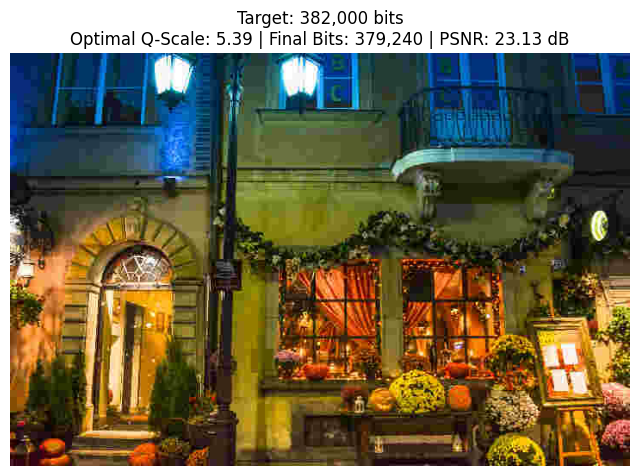

In [60]:
# Load Color Image (OpenCV loads as BGR, we convert to RGB)
bgr_img = cv2.imread('/content/drive/MyDrive/EE596 mini project/image1 (1).jpg')
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img = cv2.resize(rgb_img, (720, 480)) # SD Resolution

# Targetted bitrate = 300 + 082 (E/20/082)
target_bitrate = 382000
optimal_q, final_img, final_bits = find_optimal_qscale(img, target_bitrate)
final_psnr = calculate_psnr(img, final_img)

plt.figure(figsize=(8, 6))
plt.imshow(final_img)
plt.title(f"Target: {target_bitrate:,} bits\nOptimal Q-Scale: {optimal_q:.2f} | Final Bits: {final_bits:,} | PSNR: {final_psnr:.2f} dB")
plt.axis('off')
plt.show()


3.1.1: Three quality levels


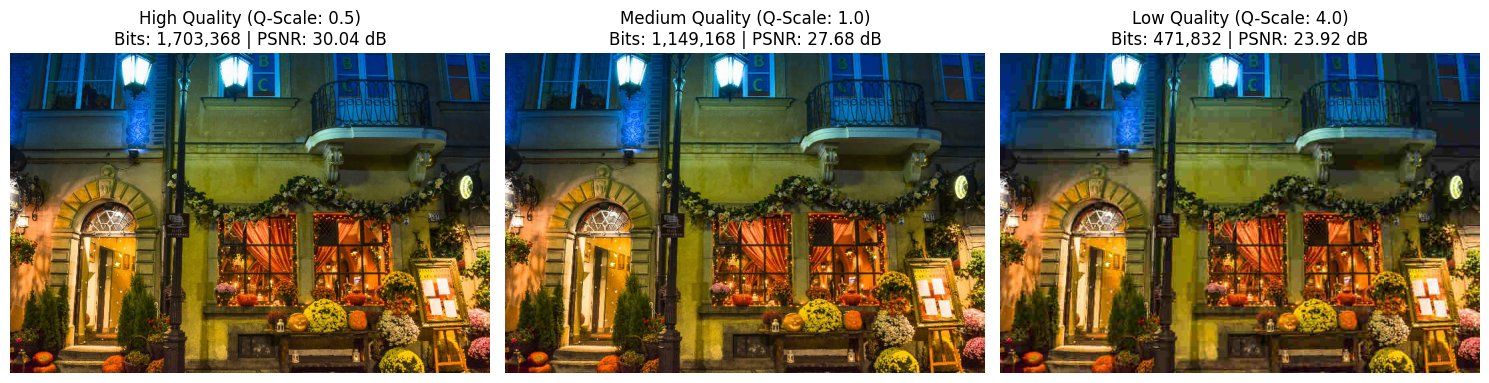

In [61]:
#Execution

# 1. Load Color Image (OpenCV loads as BGR, we must convert to RGB for Matplotlib)
bgr_img = cv2.imread('/content/drive/MyDrive/EE596 mini project/image1 (1).jpg')
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (720, 480)) # SD Resolution

print("\n3.1.1: Three quality levels")
quality_levels = {"High Quality": 0.5, "Medium Quality": 1.0, "Low Quality": 4.0}
plt.figure(figsize=(15, 5))

for idx, (label, q_scale) in enumerate(quality_levels.items()):
    recon_img, total_bits = process_color_image(img, q_scale)
    psnr = calculate_psnr(img, recon_img)

    plt.subplot(1, 3, idx + 1)
    plt.imshow(recon_img)
    plt.title(f"{label} (Q-Scale: {q_scale})\nBits: {total_bits:,} | PSNR: {psnr:.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()


3.1.2: Targetting 382 kbps
Target Bitrate: 382,000 bits
Target reached: (Iter 10 | Q: 5.39 | Bits: 379,240)


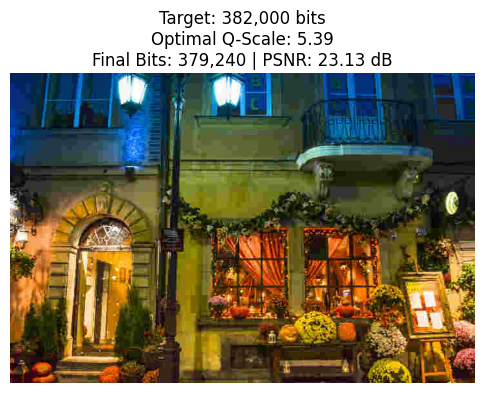

In [62]:
# Targetting bitrate = 300 + 082 = 382 kbps (E/20/082)
print("\n3.1.2: Targetting 382 kbps")
target_bitrate = 382000
optimal_q, final_img, final_bits = find_optimal_qscale(img, target_bitrate)
final_psnr = calculate_psnr(img, final_img)

plt.figure(figsize=(6, 6))
plt.imshow(final_img)
plt.title(f"Target: {target_bitrate:,} bits\nOptimal Q-Scale: {optimal_q:.2f}\nFinal Bits: {final_bits:,} | PSNR: {final_psnr:.2f} dB")
plt.axis('off')
plt.show()


3.1.3: Adapting to any bitrate

Testing Target: 150 kbps...
Target Bitrate: 150,000 bits
Target reached: (Iter 5 | Q: 16.59 | Bits: 152,056)

Testing Target: 300 kbps...
Target Bitrate: 300,000 bits
Target reached: (Iter 10 | Q: 7.33 | Bits: 299,680)

Testing Target: 600 kbps...
Target Bitrate: 600,000 bits
Target reached: (Iter 12 | Q: 2.83 | Bits: 599,792)


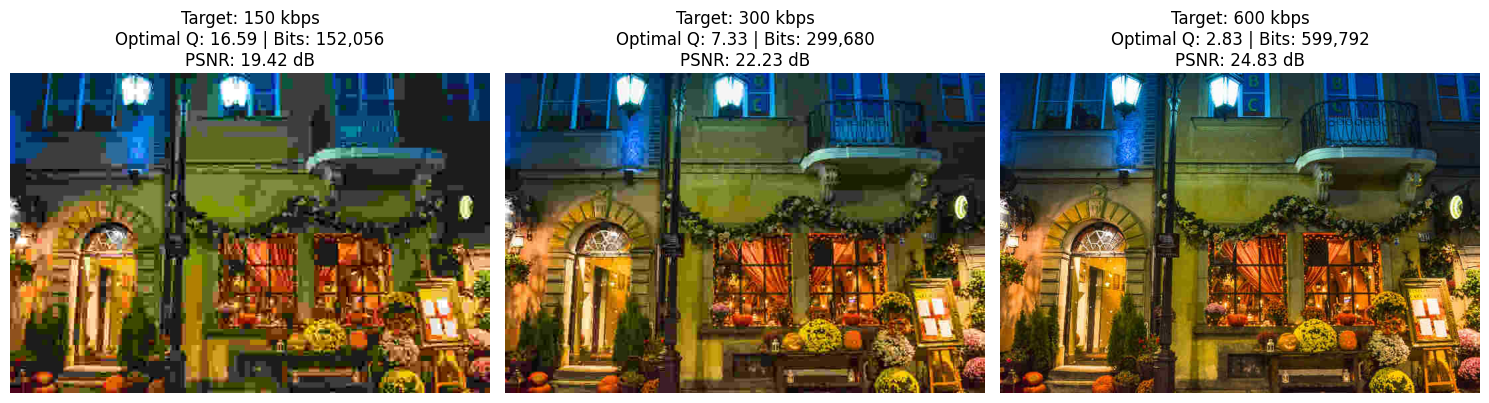

In [63]:
print("\n3.1.3: Adapting to any bitrate")
test_targets_kbps = [150, 300, 600]
plt.figure(figsize=(15, 5))

for idx, target_kbps in enumerate(test_targets_kbps):
    target_bits = target_kbps * 1000
    print(f"\nTesting Target: {target_kbps} kbps...")

    opt_q, f_img, f_bits = find_optimal_qscale(img, target_bits)
    f_psnr = calculate_psnr(img, f_img)

    plt.subplot(1, 3, idx + 1)
    plt.imshow(f_img)
    plt.title(f"Target: {target_kbps} kbps\nOptimal Q: {opt_q:.2f} | Bits: {f_bits:,}\nPSNR: {f_psnr:.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()